In [1]:
import matplotlib.pyplot as plt
import numpy as np

import time

In [2]:
labels = {'fw':'FW', 'nepfw':'NEP-FW'}
colors = {'fw':'tab:blue', 'nepfw':'tab:green'}

def plotter(res, title):
    
    fig = plt.figure()
    fig.set_figheight(6)
    fig.set_figwidth(7)

    for alg in res.keys():
        plt.plot(range(len(res[alg][2])), res[alg][2], label=labels[alg], color=colors[alg])
    
    plt.yscale('log')
    
    plt.title(title)
    plt.ylabel('')
    plt.xlabel('')
    plt.legend()

    plt.tick_params(which='minor', left=False)
    plt.grid(linestyle=':')
    
    plt.show()

In [3]:
def segment_search(f, grad_f, x, y, tol=1e-6, stepsize=True):
    '''
    Minimizes f over [x, y], i.e., f(x+gamma*(y-x)) as a function of scalar gamma in [0,1]
    '''
    d = (y-x).copy()
    left, right = x.copy(), y.copy()
    if np.dot(d, grad_f(x))*np.dot(d, grad_f(y)) >= 0:
        if f(y) <= f(x):
            return y, 1
        else:
            return x, 0
    
    # apply golden-section method to segment
    gold = (1+np.sqrt(5))/2
    improv = np.inf
    while improv > tol:
        old_left, old_right = left, right
        new = left+(right-left)/(1+gold)
        probe = new+(right-new)/2
        if f(probe) <= f(new):
            left, right = new, right
        else:
            left, right = left, probe
        improv = np.linalg.norm(f(right)-f(old_right))+np.linalg.norm(f(left)-f(old_left))
    x_min = (left+right)/2
    
    # compute step size gamma
    gamma = 0
    if stepsize == True:
        for i in range(len(d)):
            if d[i] != 0:
                gamma = (x_min[i]-x[i])/d[i]
                break
                
    return x_min, gamma

In [4]:
def FW(f, L, grad_f, x0, oracle, step, max_iter=1000, epsilon=1e-12):
    x = x0.copy()
    time_history = [time.time()]
    x_history = [x0]
    f_history = [f(x0)]
    
    for k in range(max_iter):
        g = grad_f(x)
        s = oracle["lmo"](g)
        if step == "diminishing":
            alpha = 2/(k+2)
            x = x + alpha * (s - x)
        elif step == "short":
            alpha = min(-g.dot(s - x) / (L * np.linalg.norm(s - x)**2), 1)
            x = x + alpha * (s - x)
        elif step == "line_search":
            x, alpha = segment_search(f, grad_f, x, s)
        else:
            print("Unknown step.")
            break
        
        time_history.append(time.time())
        x_history.append(x)
        f_history.append(f(x))
    return time_history, x_history, f_history

In [5]:
def NEPFW(f, L, grad_f, x0, oracle, step, max_iter=1000, epsilon = 1e-12):
    x = x0.copy()
    time_history = [time.time()]
    x_history = [x0]
    f_history = [f(x0)]
    
    for k in range(max_iter):
        g = grad_f(x)
        s = oracle["nepo"](x-((k+1)/2)*g)
        if step == "diminishing":
            alpha = 2/(k+2)
            x = x + alpha * (s - x)
        elif step == "short":
            alpha = min(-g.dot(s - x) / (L * np.linalg.norm(s - x)**2), 1)
            x = x + alpha * (s - x)
        elif step == "line_search":
            x, alpha = segment_search(f, grad_f, x, s)
        
        time_history.append(time.time())
        x_history.append(x)
        f_history.append(f(x))
    return time_history, x_history, f_history

In [6]:
def experiment1(n, p, s=None):
    np.random.seed(18)
    V = np.random.random((n+1, n))

    if not s:
        coefs_star = np.random.random(n+1)
        coefs_star /= np.sum(coefs_star)
        x_star = np.dot(coefs_star, V)
    else:
        coefs_star = np.random.random(s)
        coefs_star /= np.sum(coefs_star)
        nz = np.random.choice(n, s, replace=False)
        idx = np.isin(np.arange(n), nz)
        x_star = np.dot(coefs_star, list(compress(V, idx)))

    def f(x):
        return (1/2)*np.linalg.norm(x-x_star, p)**2

    def grad_f(x):
        return np.linalg.norm(x-x_star, p)**(2-p)*np.sign(x-x_star)*np.abs(x-x_star)**(p-1)

    def lmo(g):
        return V[np.argmin(np.dot(V, g))]

    def nepo(gg):
        return V[np.argmin([np.linalg.norm(v-gg)**2 for v in V])]
    
    oracle = {'lmo':lmo, 'nepo':nepo}
    return f, None, grad_f, V[0].copy(), oracle

In [7]:
def experiment2(n, m, s=None):
    np.random.seed(14)
    V = np.random.random((n+1, n))

    if not s:
        coefs_star = np.random.random(n+1)
        coefs_star /= np.sum(coefs_star)
        x_star = np.dot(coefs_star, V)
    else:
        coefs_star = np.random.random(s)
        coefs_star /= np.sum(coefs_star)
        nz = np.random.choice(n, s, replace=False)
        idx = np.isin(np.arange(n), nz)
        x_star = np.dot(coefs_star, list(compress(V, idx)))
    
    A = np.random.rand(m, n)
    b = A @ x_star + 0.1 * np.random.randn(m)

    def f(x):
        res = A @ x - b
        return res @ res

    def grad_f(x):
        return 2 * A.T @ (A @ x - b)

    def lmo(g):
        return V[np.argmin(np.dot(V, g))]

    def nepo(gg):
        return V[np.argmin([np.linalg.norm(v-gg)**2 for v in V])]
    
    oracle = {'lmo':lmo, 'nepo':nepo}
    return f, np.linalg.norm(2 * A.dot(A.T), ord=2), grad_f, V[0].copy(), oracle

In [8]:
from math import pi, sin, cos

def experiment3(m, N):
    np.random.seed(29)
    lengths = 10 * np.random.random(N)
    angles = np.random.random(N)
    angles *= (2 * pi) / np.sum(angles)
    
    V0 = np.zeros((N+1, 2))
    a_sum = 0
    for i in range(N - 1):
        a_sum += angles[i]
        V0[i+1][0] = V0[i][0] + cos(a_sum) * lengths[i]
        V0[i+1][1] = V0[i][1] + sin(a_sum) * lengths[i]
    index = 0
    while index < N - 3:
        if (V0[index+1][0] - V0[index][0]) * (V0[index][1] - V0[N-1][1]) <= (V0[index+1][1] - V0[index][1]) * (V0[index][0] - V0[N-1][0]):
            break
        index += 1
    V0[-1][0] = V0[index][0]
    V0[-1][1] = V0[index][1]
    
    V = V0[index:N]
    
    V0 = V0[index:].T
    fig = plt.figure()
    fig.set_figheight(6)
    fig.set_figwidth(7)

    plt.plot(V0[0], V0[1])
    plt.grid(linestyle=':')
    plt.show()

    
    coefs_star = np.random.random(N - index)
    coefs_star /= np.sum(coefs_star)
    x_star = np.dot(coefs_star, V)
    
    A = np.random.rand(m, 2)
    b = A @ x_star + 0.1 * np.random.randn(m)

    def f(x):
        res = A @ x - b
        return res @ res

    def grad_f(x):
        return 2 * A.T @ (A @ x - b)

    def lmo(g):
        return V[np.argmin(np.dot(V, g))]

    def nepo(gg):
        return V[np.argmin([np.linalg.norm(v-gg)**2 for v in V])]
    
    oracle = {'lmo':lmo, 'nepo':nepo}
    return f, np.linalg.norm(2 * A.dot(A.T), ord=2), grad_f, V[0].copy(), oracle

In [9]:
def experiment4(n, m, N, s=None):
    np.random.seed(25)
    V = np.zeros((N, n))
    vert = np.random.choice(2**n, N, replace=False)
    for i in range(N):
        for j in range(n):
            if vert[i] % 2:
                V[i][j] = 1
            vert[i] /= 2

    if not s:
        coefs_star = np.random.random(N)
        coefs_star /= np.sum(coefs_star)
        x_star = np.dot(coefs_star, V)
    else:
        coefs_star = np.random.random(s)
        coefs_star /= np.sum(coefs_star)
        nz = np.random.choice(n, s, replace=False)
        idx = np.isin(np.arange(N), nz)
        x_star = np.dot(coefs_star, list(compress(V, idx)))
    
    A = np.random.rand(m, n)
    b = A @ x_star + 0.1 * np.random.randn(m)

    def f(x):
        res = A @ x - b
        return res @ res

    def grad_f(x):
        return 2 * A.T @ (A @ x - b)

    def lmo(g):
        return V[np.argmin(np.dot(V, g))]

    def nepo(gg):
        return V[np.argmin([np.linalg.norm(v-gg)**2 for v in V])]
    
    oracle = {'lmo':lmo, 'nepo':nepo}
    return f, np.linalg.norm(2 * A.dot(A.T), ord=2), grad_f, V[0].copy(), oracle

In [10]:
def experiment5(n, m, ball_radius, on_the_boundary = False, p = 2):
    np.random.seed(33)
    A = np.random.rand(m, n)
    x_star = np.random.rand(n)
    if on_the_boundary:
        x_star = x_star / np.linalg.norm(x_star, ord=p) * ball_radius
    else:
        length = np.random.random() * ball_radius
        x_star = x_star / np.linalg.norm(x_star, ord=p) * length
    b = A @ x_star + 0.1 * np.random.randn(m)

    def f(x):
        res = A @ x - b
        return res @ res

    def grad_f(x):
        return 2 * A.T @ (A @ x - b)

    def lmo(g):
        s = g
        s[s == 0] = 1e-20
        return -ball_radius * s/np.linalg.norm(s, ord=p)

    def nepo(gg):
        s = gg
        s[s == 0] = 1e-20
        return ball_radius * s/np.linalg.norm(s, ord=p)
    
    oracle = {'lmo':lmo, 'nepo':nepo}
    return f, np.linalg.norm(2 * A.dot(A.T), ord=2), grad_f, np.zeros(n), oracle

In [53]:
n, p = 10, 16
res = {}

args = experiment1(n, p)
print('FW')
res['fw'] = FW(*args, "diminishing")
print('NEP-FW')
res['nepfw'] = NEPFW(*args, "diminishing")

FW
NEP-FW


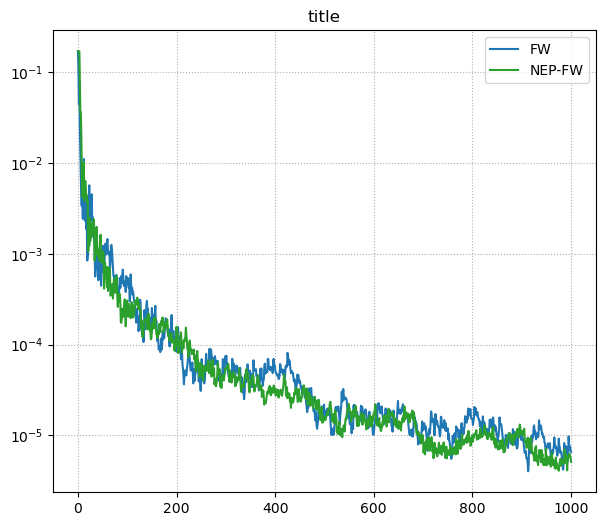

In [54]:
plotter(res, title='title')

In [49]:
n, m = 30, 20
res = {}

args = experiment2(n, m)
print('FW')
res['fw'] = FW(*args, "diminishing")
print('NEP-FW')
res['nepfw'] = NEPFW(*args, "diminishing")

FW
NEP-FW


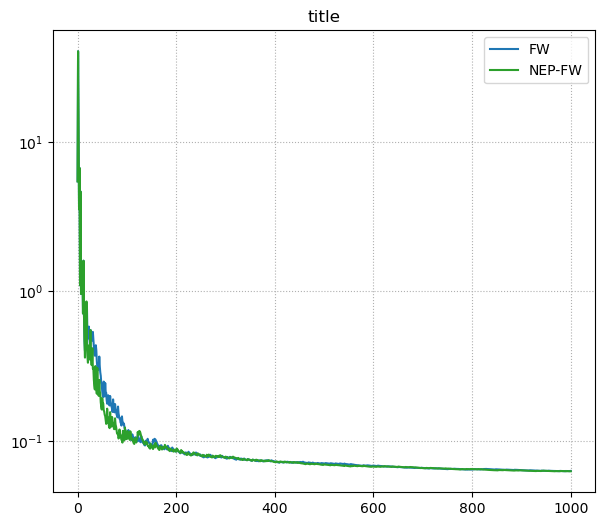

In [50]:
plotter(res, title='title')

In [51]:
res = {}

print('FW')
res['fw'] = FW(*args, "line_search")
print('NEP-FW')
res['nepfw'] = NEPFW(*args, "line_search")

FW
NEP-FW


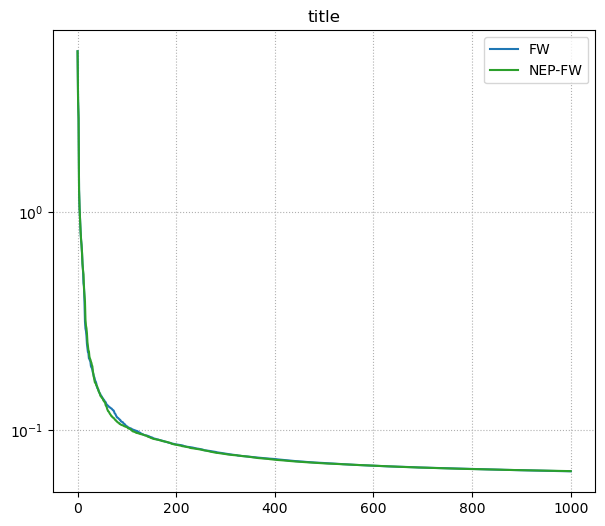

In [52]:
plotter(res, title='title')

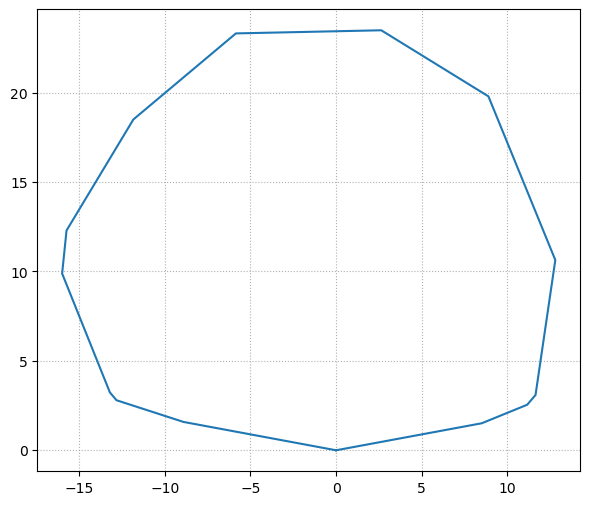

FW
NEP-FW


In [17]:
m, N = 15, 15
res = {}

args = experiment3(m, N)
print('FW')
res['fw'] = FW(*args, "short", max_iter=100)
print('NEP-FW')
res['nepfw'] = NEPFW(*args, "short", max_iter=100)

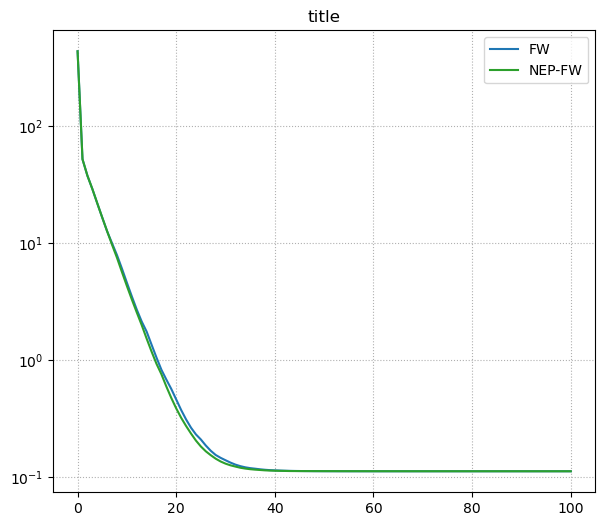

In [18]:
plotter(res, title='title')

In [19]:
n, m, N = 6, 4, 8
res = {}

args = experiment4(n, m, N)
print('FW')
res['fw'] = FW(*args, "short", max_iter=100)
print('NEP-FW')
res['nepfw'] = NEPFW(*args, "short", max_iter=100)

FW
NEP-FW


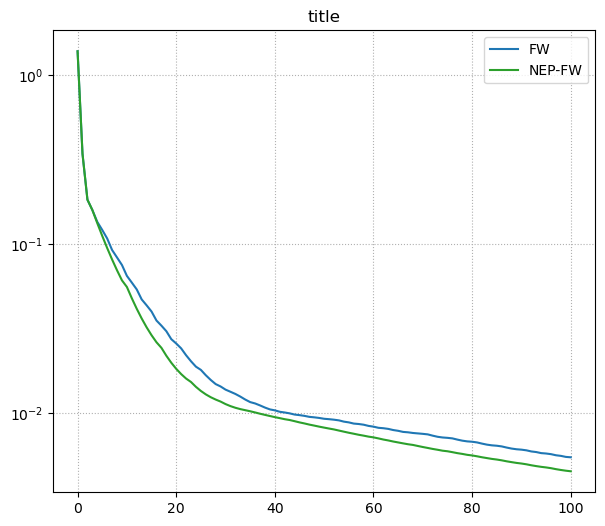

In [20]:
plotter(res, title='title')

In [41]:
n, m = 6, 4
res = {}

args = experiment5(n, m, 5, True, 2)
print('FW')
res['fw'] = FW(*args, "short", max_iter=1000)
print('NEP-FW')
res['nepfw'] = NEPFW(*args, "short", max_iter=1000)

FW
NEP-FW


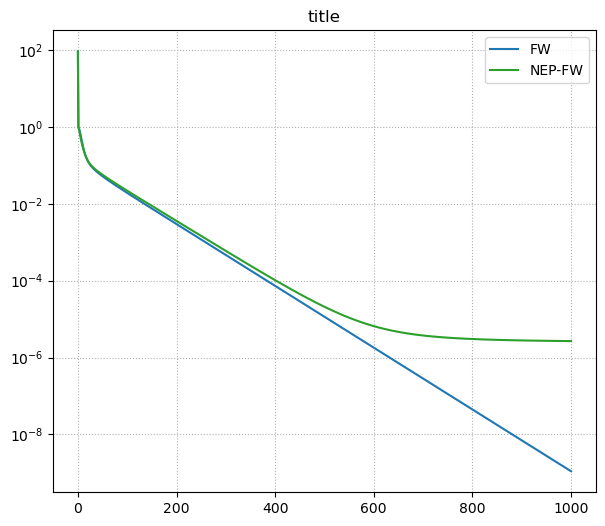

In [42]:
plotter(res, title='title')

In [43]:
n, m = 6, 4
res = {}

args = experiment5(n, m, 5, False, 7)
print('FW')
res['fw'] = FW(*args, "short", max_iter=1000)
print('NEP-FW')
res['nepfw'] = NEPFW(*args, "short", max_iter=1000)

FW
NEP-FW


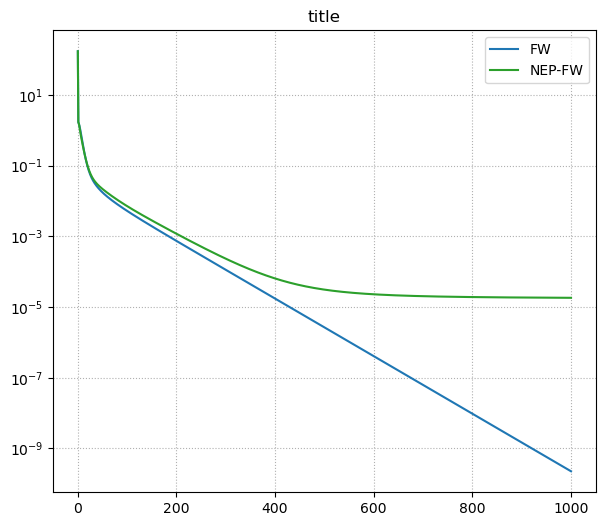

In [44]:
plotter(res, title='title')

In [47]:
n, m = 6, 4
res = {}

args = experiment5(n, m, 5, False, 1.02)
print('FW')
res['fw'] = FW(*args, "short", max_iter=1000)
print('NEP-FW')
res['nepfw'] = NEPFW(*args, "short", max_iter=1000)

FW
NEP-FW


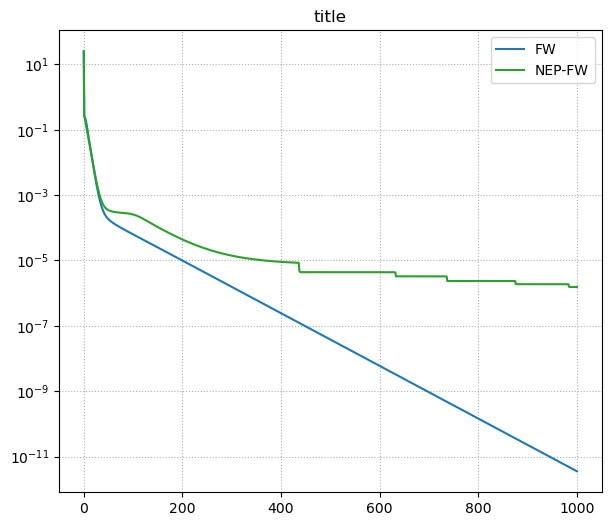

In [48]:
plotter(res, title='title')